In [1]:
import wrds

# Connect to WRDS
db = wrds.Connection()

WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [2]:
import pandas as pd

# Get S&P 500 tickers from Wikipedia
sp500_list = pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")[0]
sp500_tickers = sp500_list[['Symbol', 'Security']]
sp500_tickers.columns = ['tic', 'company']


In [3]:
import pandas as pd

# Get S&P 500 tickers from Wikipedia
sp500_list = pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")[0]
sp500_tickers = sp500_list[['Symbol', 'Security']]
sp500_tickers.columns = ['ticker', 'company']


In [4]:
# Clean up ticker list for SQL format
tickers = tuple(sp500_tickers['ticker'].tolist())

# Query CRSP stocknames to map ticker to permno
crsp_ids = db.raw_sql(f"""
    SELECT permno, permco, cusip, ticker, namedt, nameenddt
    FROM crsp.stocknames
    WHERE ticker IN {tickers}
""")


In [5]:
# Convert permno values to plain Python ints
permnos = tuple(int(x) for x in crsp_ids['permno'].unique())

# Query CRSP monthly stock file
stock_prices = db.raw_sql(f"""
    SELECT permno, date, prc, vol, ret, shrout
    FROM crsp.msf
    WHERE date >= '2014-01-01' AND permno IN {permnos}
""")

stock_prices['date'] = pd.to_datetime(stock_prices['date'])


In [6]:
financials = db.raw_sql("""
    SELECT gvkey, datadate, tic, at, lt, seq, ni, mkvalt
    FROM comp.funda
    WHERE datadate >= '2014-01-01'
    AND indfmt = 'INDL' AND datafmt = 'STD'
    AND popsrc = 'D' AND consol = 'C'
""")


In [7]:
# Convert dates
financials['datadate'] = pd.to_datetime(financials['datadate'])

# Calculate ratios
financials['de_ratio'] = financials['lt'] / financials['seq']
financials['roe'] = financials['ni'] / financials['seq']
financials['pe_ratio'] = financials['mkvalt'] / financials['ni']


In [8]:
# Assuming you still have these:
# - stock_prices: from crsp.msf
# - crsp_ids: from crsp.stocknames
# - sp500_tickers: from Wikipedia

# Merge permno with ticker from stocknames
stock_data = stock_prices.merge(
    crsp_ids[['permno', 'ticker']],
    on='permno',
    how='left'
)

# Merge with company names (optional)
stock_data = stock_data.merge(
    sp500_tickers,
    on='ticker',
    how='left'
)


In [9]:
# Rename 'tic' to 'ticker' to match stock_data
financials.rename(columns={'tic': 'ticker'}, inplace=True)


In [10]:
# Ensure both 'ticker' columns are string type
stock_data['ticker'] = stock_data['ticker'].astype(str)
financials['ticker'] = financials['ticker'].astype(str)


In [11]:
# Sort before merge_asof
stock_data = stock_data.sort_values("date")
financials = financials.sort_values("datadate")

# Merge using nearest match on date and exact match on ticker
merged_df = pd.merge_asof(
    stock_data,
    financials,
    left_on='date',
    right_on='datadate',
    by='ticker',
    direction='backward'
)


In [12]:
# Define the features we'll use
features = ['prc', 'vol', 'ret', 'mkvalt', 'roe', 'pe_ratio', 'de_ratio']

# Drop rows with any missing values in these columns
merged_clean = merged_df.dropna(subset=features)


In [13]:
from sklearn.preprocessing import StandardScaler

# Extract feature matrix
X = merged_clean[features]

# Initialize and apply scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Optionally add scaled features to the DataFrame for inspection
for i, col in enumerate(features):
    merged_clean[col + '_scaled'] = X_scaled[:, i]


C:\Users\student\AppData\Local\Temp\ipykernel_9580\3668225840.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_clean[col + '_scaled'] = X_scaled[:, i]
C:\Users\student\AppData\Local\Temp\ipykernel_9580\3668225840.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_clean[col + '_scaled'] = X_scaled[:, i]
C:\Users\student\AppData\Local\Temp\ipykernel_9580\3668225840.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

In [14]:
merged_clean.to_csv("sp500_cluster_ready.csv", index=False)


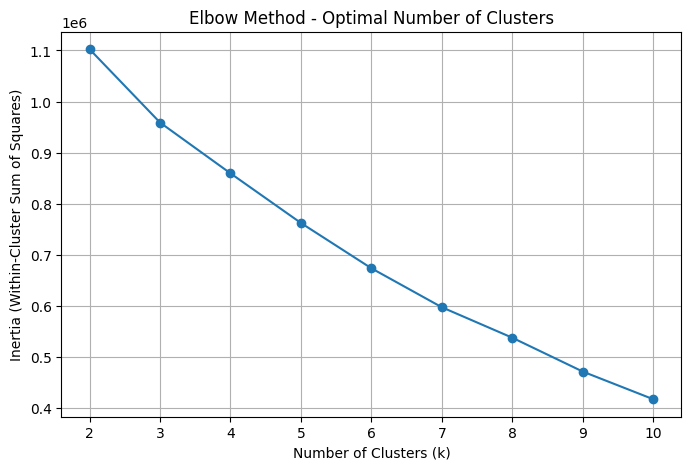

In [15]:
import numpy as np

# Sample 5,000 rows for quick computation (you can adjust this)
sample_idx = np.random.choice(len(X_scaled), size=5000, replace=False)
X_sample = X_scaled[sample_idx]

# Then use X_sample in silhouette score loop
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    sil_scores.append(score)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker='o')
plt.title('Silhouette Score (Sampled Data)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()


In [19]:
# Run KMeans with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
merged_clean['cluster'] = kmeans.fit_predict(X_scaled)


C:\Users\student\AppData\Local\Temp\ipykernel_9580\561970094.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_clean['cluster'] = kmeans.fit_predict(X_scaled)


In [20]:
cluster_summary = merged_clean.groupby('cluster')[features].mean()
print(cluster_summary)


                 prc              vol       ret         mkvalt         roe  \
cluster                                                                      
0         124.626604    752457.458703  0.012211   47998.949593    0.096231   
1         214.872499    215427.083333  0.043588       30816.32  216.142857   
2          10.699817    842256.833333 -0.009363       11020.19       388.7   
3          66.227915  11173876.389401   0.00781  348752.383444    0.108215   
4        2534.619321    127037.299688  0.027175   189712.76627    0.303614   

          pe_ratio     de_ratio  
cluster                          
0        23.261379     1.539204  
1        -6.789231 -3027.095238  
2          2.83514        772.5  
3        31.740142     4.474851  
4        53.440138     0.273837  


In [21]:
merged_clean['cluster'].value_counts().sort_index()


cluster
0    179046
1        48
2        24
3      4340
4       961
Name: count, dtype: int64

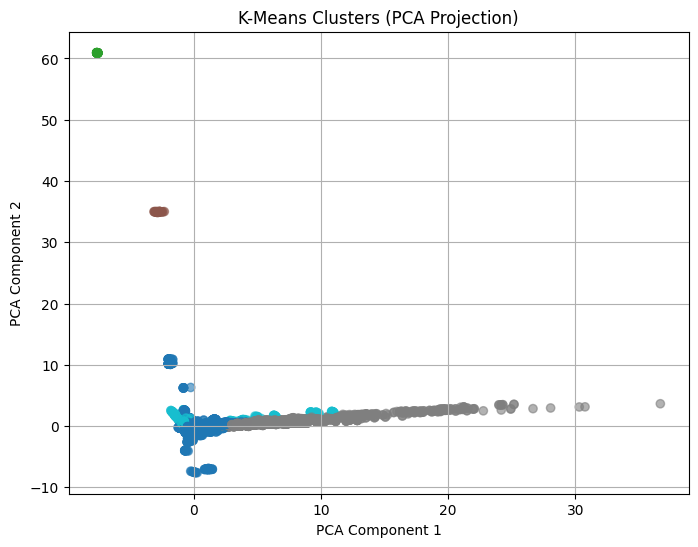

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=merged_clean['cluster'], cmap='tab10', alpha=0.6)
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


In [23]:
print(pd.DataFrame(pca.components_, columns=features, index=['PC1', 'PC2']))


          prc       vol       ret    mkvalt       roe  pe_ratio  de_ratio
PC1 -0.029594  0.706425 -0.035631  0.696636 -0.059233  0.024703  0.096938
PC2  0.063079  0.058436  0.017898  0.100947  0.703096  0.009731 -0.698324


In [30]:
print(merged_clean.head())


    permno       date    prc        vol       ret    shrout ticker   company  \
10   16678 2014-01-31   36.1   930455.0  -0.08677  516526.0     KR    Kroger   
22   16678 2014-01-31   36.1   930455.0  -0.08677  516526.0     KR    Kroger   
45   86580 2014-01-31   15.7  1340261.0 -0.019975  567997.0   NVDA    Nvidia   
58   85631 2014-01-31  51.25   583054.0  0.018502  226700.0   ADSK  Autodesk   
87   85914 2014-01-31  23.54  3536774.0 -0.409729  346008.0    BBY  Best Buy   

     gvkey   datadate  ...       roe   pe_ratio  prc_scaled  vol_scaled  \
10  006502 2014-01-31  ...  0.282132  12.072943   -0.417539   -0.031398   
22  006502 2014-01-31  ...  0.282132  12.072943   -0.417539   -0.031398   
45  117768 2014-01-31  ...  0.098732  20.267626   -0.502957    0.170071   
58  001878 2014-01-31  ...  0.101172  50.779611   -0.354104   -0.202187   
87  002184 2014-01-31  ...  0.133467   15.34308   -0.470130    1.249918   

    ret_scaled  mkvalt_scaled  roe_scaled  pe_ratio_scaled  de_ratio

In [31]:
print(merged_clean.columns)

Index(['permno', 'date', 'prc', 'vol', 'ret', 'shrout', 'ticker', 'company',
       'gvkey', 'datadate', 'at', 'lt', 'seq', 'ni', 'mkvalt', 'de_ratio',
       'roe', 'pe_ratio', 'prc_scaled', 'vol_scaled', 'ret_scaled',
       'mkvalt_scaled', 'roe_scaled', 'pe_ratio_scaled', 'de_ratio_scaled',
       'cluster'],
      dtype='object')


In [32]:
# Selecting outliers based on extreme percentiles in key financial metrics
outliers = merged_clean[
    (merged_clean['mkvalt'] > merged_clean['mkvalt'].quantile(0.99)) |  # Largest firms
    (merged_clean['vol'] > merged_clean['vol'].quantile(0.99)) |        # Highly traded
    (merged_clean['roe'] > merged_clean['roe'].quantile(0.99)) |        # High profitability
    (merged_clean['de_ratio'] > merged_clean['de_ratio'].quantile(0.99))  # High debt
]

# Display outliers
print(outliers[['ticker', 'company', 'mkvalt', 'vol', 'roe', 'de_ratio']])


       ticker           company       mkvalt         vol       roe   de_ratio
8337      CLX            Clorox   11771.9544    218330.0  3.623377  26.649351
11307     CLX            Clorox   11771.9544    181906.0  3.623377  26.649351
12010     CLX            Clorox   11771.9544    191235.0  3.623377  26.649351
13373    AAPL        Apple Inc.  591015.7208  15283673.0    0.3542   1.078397
13374    AAPL        Apple Inc.  591015.7208  15283673.0    0.3542   1.078397
...       ...               ...          ...         ...       ...        ...
218638    WMT           Walmart    443696.25   3821318.0  0.184961   1.929717
218639    WMT           Walmart    443696.25   3821318.0  0.184961   1.929717
218668   VRSK  Verisk Analytics   38674.5035    150026.0  9.572428  41.555445
218669   VRSK  Verisk Analytics   38674.5035    150026.0  9.572428  41.555445
218755   TSLA       Tesla, Inc.   1298749.44  18946442.0  0.097253   0.663668

[6147 rows x 6 columns]


In [33]:
# Example mapping — replace this with a full sector mapping or pull from WRDS
sector_map = {
    'AAPL': 'Information Technology',
    'TSLA': 'Consumer Discretionary',
    'WMT': 'Consumer Staples',
    'CLX': 'Consumer Staples',
    'VRSK': 'Industrials',
    # ... add more tickers
}

# Add sector to merged_clean
merged_clean['sector'] = merged_clean['ticker'].map(sector_map)

# Check distribution
print(merged_clean.groupby(['cluster', 'sector']).size().unstack(fill_value=0))


sector   Consumer Discretionary  Consumer Staples  Industrials  \
cluster                                                          
0                           136               901          242   
3                           104                18            0   
4                             2                 0            0   

sector   Information Technology  
cluster                          
0                             0  
3                           248  
4                             0  


C:\Users\student\AppData\Local\Temp\ipykernel_9580\1550202132.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_clean['sector'] = merged_clean['ticker'].map(sector_map)
